In [1]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.time import Time
import pandas as pd
import os
from tp7.tp7 import Tape7
import scipy.integrate as integrate

In [2]:
def modtran_data_files(path: str) -> list:
    files = [path + "/" + file for file in os.listdir(path) if file.endswith(".tp7")]
    return files

In [3]:
a00_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA00")
a41_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA41")
a60_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA60")
a75_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA75")
a85_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA85")

In [4]:
def plot_radiance(rads, title, runnum):
    #access wavelength with rads[:,0,runnum], swrad with rads[:,1,runnum], lwrad with rads[:,2,runnum]
    # print('')
    # print(describer_df)
    # print(np.shape(rads))
    print(np.shape(rads), print(runnum))
    figure = plt.figure(2, figsize=(14,10))
    ax = plt.axes()
    ax.plot(rads[:,0,runnum], rads[:,1, runnum], 'r-', label='SW Radiance')
    #ax.plot(rads[:,0,runnum], rads[:,2, runnum], 'b-', label='LW Radiance')
    ax.legend(prop={"size":20})
    plt.title("%s Radiance Spectrum"%title, fontsize=40)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.xlabel('Wavelength um', fontsize=30)
    plt.ylabel('Radiance $W m^{-2} um^{-1} sr^{-1}$', fontsize=30)
    plt.xlim(0,5)

In [5]:
a00_data = [Tape7(file) for file in a00_files]

In [6]:
a00_data

In [7]:
titles = [file.title for file in a00_data]
a00 = {title: file for title, file in zip(titles, a00_data)}

In [8]:
a00

{'Clear Ocean': <tp7.tp7.Tape7 at 0x73ac94711d80>,
 'Land': <tp7.tp7.Tape7 at 0x73ac94711d50>,
 'Cloudy Ocean': <tp7.tp7.Tape7 at 0x73acd426f9a0>,
 'Snow': <tp7.tp7.Tape7 at 0x73acd46a9480>,
 'Deep Convective Cloud': <tp7.tp7.Tape7 at 0x73acd46abcd0>}

In [9]:
land = a00["Land"]
land.title

'Land'

In [10]:
land.build_scene_description()
land.compute_radiences()

array([[[1.00000000e+03, 1.00000000e+03, 1.00000000e+03, ...,
         1.00000000e+03, 1.00000000e+03, 1.00000000e+03],
        [1.25208003e-24, 1.21169035e-24, 1.21169035e-24, ...,
         4.68860000e-24, 5.16990000e-24, 5.16780000e-24],
        [2.13490000e-06, 2.13410000e-06, 2.13200000e-06, ...,
         1.85090000e-06, 1.86720000e-06, 1.86700000e-06]],

       [[5.00000000e+02, 5.00000000e+02, 5.00000000e+02, ...,
         5.00000000e+02, 5.00000000e+02, 5.00000000e+02],
        [2.34488000e-22, 2.28208000e-22, 2.24880000e-22, ...,
         7.54000000e-22, 7.99800000e-22, 7.99800000e-22],
        [3.15152000e-05, 3.14864000e-05, 3.14020000e-05, ...,
         2.78224000e-05, 2.81280000e-05, 2.81280000e-05]],

       [[3.33333333e+02, 3.33333333e+02, 3.33333333e+02, ...,
         3.33333333e+02, 3.33333333e+02, 3.33333333e+02],
        [4.79943000e-21, 4.75173000e-21, 4.69422000e-21, ...,
         1.36341000e-20, 1.39023000e-20, 1.39023000e-20],
        [1.49130000e-04, 1.49049000e

629
(4000, 3, 630) None


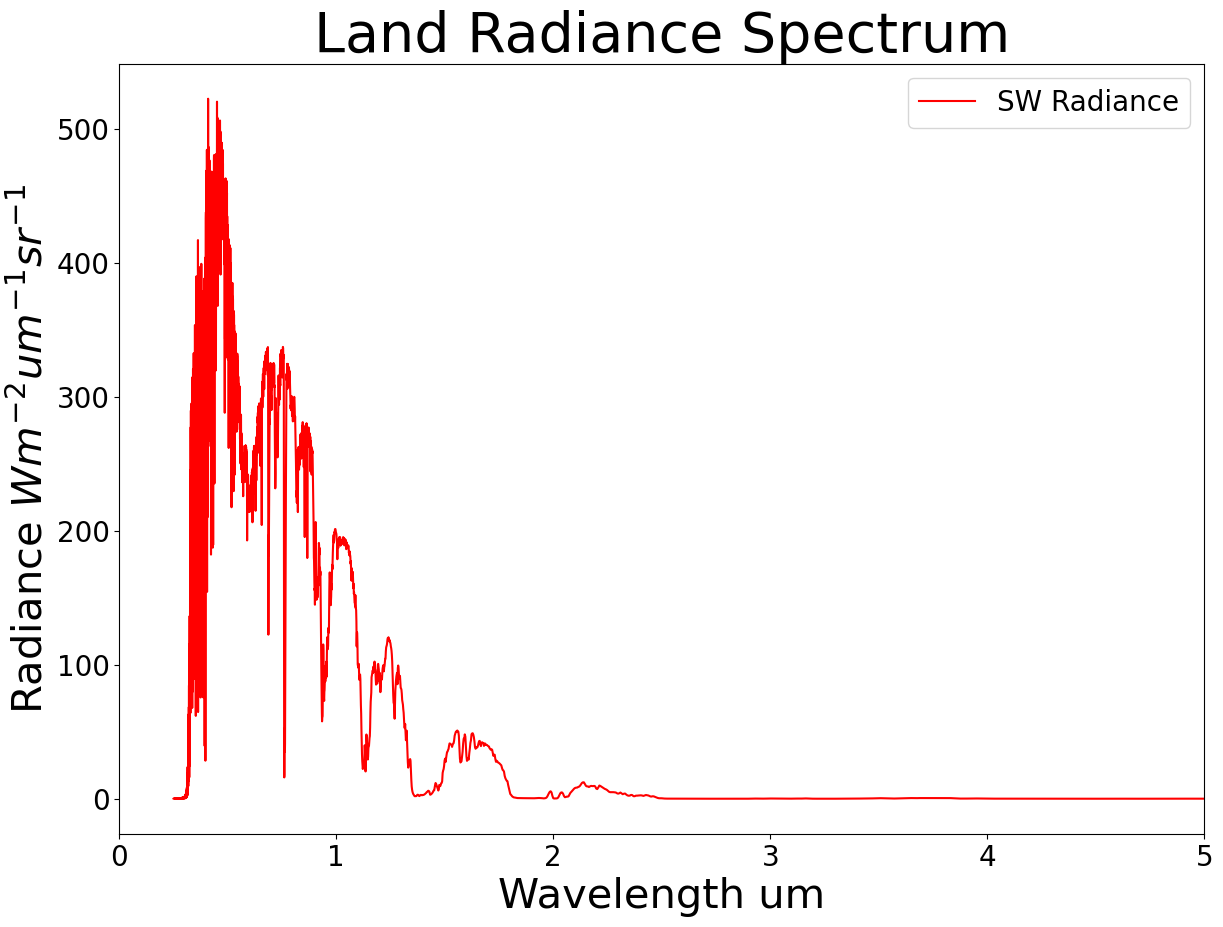

In [11]:
plot_radiance(land.rads, land.title, land.num_runs - 1)

In [31]:
wavelength_run_629 = land.rads[:, 0, 629]
sw_run_629 = land.rads[:, 1, 629]

integral_value = integrate.simpson(y=wavelength_run_629, x=sw_run_629)

In [34]:
np.savetxt("./data/wv629.txt", wavelength_run_629)

In [13]:
integral_value

239.18537580630823

In [14]:
land_wvln = land.rads[:, 0, :]
land_sw = land.rads[:, 1, :]
land_lw = land.rads[:, 2, :]

print(np.shape(land_sw), np.shape(land_lw))

land00_sw_unfiltered_radiances = [integrate.simpson(y=land_wvln[:, i] , x=land_sw[:, i]) for i in range(land_sw.shape[1] - 1)]
land00_lw_unfiltered_radiances = [integrate.simpson(y=land_wvln[:, i] , x=land_lw[:, i]) for i in range(land_lw.shape[1] - 1)]

(4000, 630) (4000, 630)


In [15]:
land00_sw_unfiltered_radiances

[102.31928527530097,
 103.81387839774891,
 159.1481486000823,
 316.03906076224393,
 346.6548942330293,
 78.28261684756308,
 86.33920502378857,
 146.7643543013044,
 297.68783674244526,
 345.91817420965356,
 97.883585719143,
 103.58348479851017,
 156.50672638701624,
 264.8629911171979,
 352.5154550053464,
 42.84141527262163,
 65.0791584978992,
 137.18455406926483,
 273.16643683766875,
 359.4977435186633,
 52.43058603583969,
 71.21537740172506,
 138.23317718956307,
 273.7369499131099,
 359.4977435186633,
 78.60543380278251,
 84.24453612979298,
 148.49214217023027,
 288.5505723839168,
 363.28995198524325,
 101.96802259492922,
 102.01948861238517,
 157.8260054914294,
 260.03853527008044,
 342.1006046066565,
 89.10229639403663,
 85.16142889370154,
 147.46997975144322,
 278.70406365817024,
 340.7090202184633,
 96.27531346312908,
 101.81669574775715,
 156.3754680797762,
 269.8699053141981,
 346.87087961248864,
 42.32444550113939,
 66.46201442229952,
 137.81335108185428,
 280.8166444473849,
 35

In [16]:
land00_lw_unfiltered_radiances

[248861.02903757937,
 70.38431111042331,
 60.635739955067386,
 94.06799233688763,
 86.594535292493,
 31624993.316934895,
 1465.981816519733,
 60.62204717444198,
 93.97803314923794,
 86.594535292493,
 253991604.7878418,
 70.09367038852429,
 59.34556293633371,
 84.62798876963733,
 71.09108363568365,
 3612621.799441942,
 57.998856299889106,
 50.159436776232326,
 79.87772496780218,
 66.02135584332537,
 3571655.830453963,
 57.75323218572574,
 50.140735203682624,
 80.44183994114087,
 66.0213562406714,
 -8249897.205815155,
 54.11060959705119,
 46.973732396680965,
 72.91487883559039,
 68.6288226932692,
 100381758.93555467,
 67.43771543118872,
 60.02857505960181,
 91.97855463771776,
 86.25541815469609,
 24074394.945013564,
 67.23534455409741,
 59.81812473936557,
 92.00739667567723,
 86.25541815469609,
 -11510629.094461966,
 67.91971167116974,
 59.622508403527206,
 89.46412244406646,
 82.84328960488662,
 -51144.154422958425,
 57.18699362953314,
 49.85625241343769,
 80.92868429454337,
 72.5944099

In [17]:
land00_describer = land.describer_df

In [18]:
land00_describer

,Scene,SZA,VZA,RAZ,Atm model,Sfc Temp,Albedo model,Season,Aerosol Type,Met Range,Wind spd (ms-1),Cld Type,Cld Alt (km),Cld Thick (km),Cld Ext Coef (km-1),Run #
0,Land,0.0,0.000,0.0,Tropical,310.0,-2.0,Spring/Summer,Desert,37.82713,5.0,No cloud,0.00,0.00,0.0,0
1,Land,0.0,0.000,0.0,Tropical,310.0,-2.0,Spring/Summer,Desert,37.82713,5.0,ICLD 18: cirrus cloud,7.00,1.00,4.0,1
2,Land,0.0,0.000,0.0,Tropical,310.0,-2.0,Spring/Summer,Desert,37.82713,5.0,ICLD 18: cirrus cloud,7.00,2.00,6.0,2
3,Land,0.0,0.000,0.0,Tropical,310.0,-2.0,Spring/Summer,Desert,37.82713,5.0,ICLD 3: stratus cloud,0.50,0.20,28.0,3
4,Land,0.0,0.000,0.0,Tropical,310.0,-2.0,Spring/Summer,Desert,37.82713,5.0,ICLD 1: cumulus cloud,0.66,2.34,92.6,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
625,Land,0.0,79.914,172.5,Midlatitude Winter,275.0,-7.0,Fall/Winter,Rural,25.00000,0.0,No cloud,0.00,0.00,0.0,625
626,Land,0.0,79.914,172.5,Midlatitude Winter,275.0,-7.0,Fall/Winter,Rural,25.00000,0.0,ICLD 18: cirrus cloud,7.00,1.00,4.0,626
627,Land,0.0,79.914,172.5,Midlatitude Winter,275.0,-7.0,Fall/Winter,Rural,25.00000,0.0,ICLD 18: cirrus cloud,7.00,2.00,6.0,627
628,Land,0.0,79.914,172.5,Midlatitude Winter,275.0,-7.0,Fall/Winter,Rural,25.00000,0.0,ICLD 3: stratus cloud,0.50,0.20,28.0,628


In [19]:
srfs = pd.read_csv("./data/libera_srfs_20241017.csv")

In [20]:
srfs

,wavelength [um],ssw srf,conv ssw srf,lw srf,conv lw srf,total srf,conv total srf,sw srf,conv sw srf
0,0.300000,0.0,0.0,0.00000,0.00000,0.00860,0.00865,0.01079,0.01076
1,0.301750,0.0,0.0,0.00000,0.00000,0.00965,0.00965,0.01006,0.01006
2,0.303509,0.0,0.0,0.00000,0.00000,0.01077,0.01076,0.00933,0.00933
3,0.305279,0.0,0.0,0.00000,0.00000,0.01182,0.01178,0.00863,0.00865
4,0.307060,0.0,0.0,0.00000,0.00000,0.01218,0.01218,0.00818,0.00818
...,...,...,...,...,...,...,...,...,...
995,97.700859,0.0,0.0,0.44098,0.45646,0.89716,0.89719,-0.00000,-0.00000
996,98.270641,0.0,0.0,0.50463,0.49343,0.89582,0.89590,-0.00000,-0.00000
997,98.843745,0.0,0.0,0.56496,0.52561,0.89447,0.89473,-0.00000,-0.00000
998,99.420192,0.0,0.0,0.57120,0.54465,0.89312,0.89376,-0.00000,-0.00000


In [21]:
for index, row in srfs.iterrows():
    next_index = index + 1
    if next_index not in srfs.index:
        continue
    else:
        srfs.loc[index, 'End_wv_range'] = srfs.loc[next_index, 'wavelength [um]']

In [22]:
srfs

,wavelength [um],ssw srf,conv ssw srf,lw srf,conv lw srf,total srf,conv total srf,sw srf,conv sw srf,End_wv_range
0,0.300000,0.0,0.0,0.00000,0.00000,0.00860,0.00865,0.01079,0.01076,0.301750
1,0.301750,0.0,0.0,0.00000,0.00000,0.00965,0.00965,0.01006,0.01006,0.303509
2,0.303509,0.0,0.0,0.00000,0.00000,0.01077,0.01076,0.00933,0.00933,0.305279
3,0.305279,0.0,0.0,0.00000,0.00000,0.01182,0.01178,0.00863,0.00865,0.307060
4,0.307060,0.0,0.0,0.00000,0.00000,0.01218,0.01218,0.00818,0.00818,0.308850
...,...,...,...,...,...,...,...,...,...,...
995,97.700859,0.0,0.0,0.44098,0.45646,0.89716,0.89719,-0.00000,-0.00000,98.270641
996,98.270641,0.0,0.0,0.50463,0.49343,0.89582,0.89590,-0.00000,-0.00000,98.843745
997,98.843745,0.0,0.0,0.56496,0.52561,0.89447,0.89473,-0.00000,-0.00000,99.420192
998,99.420192,0.0,0.0,0.57120,0.54465,0.89312,0.89376,-0.00000,-0.00000,100.000000


In [57]:
sw_run_629

array([5.16780000e-24, 7.99800000e-22, 1.39023000e-20, ...,
       3.29590162e-02, 3.23294292e-02, 3.43072000e-02])

In [24]:
# for i in wavelength_run_629:
#     print(i)
new_row = srfs.iloc[0].copy()
new_row.loc['End_wv_range'] = new_row['wavelength [um]']
new_row.loc['wavelength [um]'] = 0.0
data, cols = new_row.values, new_row.index
print(cols)
tdf = pd.DataFrame([data], columns=cols)
# new_row = new_row.reset_index()
# tdf = pd.DataFrame(new_row.values, columns=new_row.index)
srfs = pd.concat([tdf, srfs])
srfs

Index(['wavelength [um]', ' ssw srf', ' conv ssw srf', ' lw srf',
       ' conv lw srf', ' total srf', ' conv total srf', ' sw srf',
       ' conv sw srf', 'End_wv_range'],
      dtype='object')


,wavelength [um],ssw srf,conv ssw srf,lw srf,conv lw srf,total srf,conv total srf,sw srf,conv sw srf,End_wv_range
0,0.000000,0.0,0.0,0.00000,0.00000,0.00860,0.00865,0.01079,0.01076,0.300000
0,0.300000,0.0,0.0,0.00000,0.00000,0.00860,0.00865,0.01079,0.01076,0.301750
1,0.301750,0.0,0.0,0.00000,0.00000,0.00965,0.00965,0.01006,0.01006,0.303509
2,0.303509,0.0,0.0,0.00000,0.00000,0.01077,0.01076,0.00933,0.00933,0.305279
3,0.305279,0.0,0.0,0.00000,0.00000,0.01182,0.01178,0.00863,0.00865,0.307060
...,...,...,...,...,...,...,...,...,...,...
995,97.700859,0.0,0.0,0.44098,0.45646,0.89716,0.89719,-0.00000,-0.00000,98.270641
996,98.270641,0.0,0.0,0.50463,0.49343,0.89582,0.89590,-0.00000,-0.00000,98.843745
997,98.843745,0.0,0.0,0.56496,0.52561,0.89447,0.89473,-0.00000,-0.00000,99.420192
998,99.420192,0.0,0.0,0.57120,0.54465,0.89312,0.89376,-0.00000,-0.00000,100.000000


In [25]:
srfs.to_csv("./data/srfs.csv")

In [22]:
np.shape(wavelength_run_629)

(4000,)

In [26]:
for i in range(len(wavelength_run_629)):
    print(wavelength_run_629[i])

1000.0
500.0
333.3333333333333
250.0
200.0
166.66666666666666
142.85714285714286
125.0
111.11111111111111
100.0
90.9090909090909
83.33333333333333
76.92307692307693
71.42857142857143
66.66666666666667
62.5
58.8235294117647
55.55555555555556
52.63157894736842
50.0
47.61904761904762
45.45454545454545
43.47826086956522
41.666666666666664
40.0
38.46153846153847
37.03703703703704
35.714285714285715
34.48275862068965
33.333333333333336
32.25806451612903
31.25
30.303030303030305
29.41176470588235
28.571428571428573
27.77777777777778
27.027027027027028
26.31578947368421
25.641025641025642
25.0
24.390243902439025
23.80952380952381
23.25581395348837
22.727272727272727
22.22222222222222
21.73913043478261
21.27659574468085
20.833333333333332
20.408163265306126
20.0
19.607843137254903
19.230769230769234
18.867924528301888
18.51851851851852
18.181818181818183
17.857142857142858
17.54385964912281
17.241379310344826
16.949152542372882
16.666666666666668
16.39344262295082
16.129032258064516
15.87301587

In [28]:
min(wavelength_run_629)

0.25

In [30]:
.3 in wavelength_run_629

False

In [40]:
srfs.columns

Index(['wavelength [um]', ' ssw srf', ' conv ssw srf', ' lw srf',
       ' conv lw srf', ' total srf', ' conv total srf', ' sw srf',
       ' conv sw srf', 'End_wv_range'],
      dtype='object')

In [42]:
srfs

,wavelength [um],ssw srf,conv ssw srf,lw srf,conv lw srf,total srf,conv total srf,sw srf,conv sw srf,End_wv_range
0,0.000000,0.0,0.0,0.00000,0.00000,0.00860,0.00865,0.01079,0.01076,0.300000
0,0.300000,0.0,0.0,0.00000,0.00000,0.00860,0.00865,0.01079,0.01076,0.301750
1,0.301750,0.0,0.0,0.00000,0.00000,0.00965,0.00965,0.01006,0.01006,0.303509
2,0.303509,0.0,0.0,0.00000,0.00000,0.01077,0.01076,0.00933,0.00933,0.305279
3,0.305279,0.0,0.0,0.00000,0.00000,0.01182,0.01178,0.00863,0.00865,0.307060
...,...,...,...,...,...,...,...,...,...,...
995,97.700859,0.0,0.0,0.44098,0.45646,0.89716,0.89719,-0.00000,-0.00000,98.270641
996,98.270641,0.0,0.0,0.50463,0.49343,0.89582,0.89590,-0.00000,-0.00000,98.843745
997,98.843745,0.0,0.0,0.56496,0.52561,0.89447,0.89473,-0.00000,-0.00000,99.420192
998,99.420192,0.0,0.0,0.57120,0.54465,0.89312,0.89376,-0.00000,-0.00000,100.000000


In [41]:
srfs.loc[999, 'End_wv_range'] = 110

In [47]:
wvs629 = pd.read_csv("./data/wv629.txt", header=None).squeeze()

In [50]:
np.shape(wvs629)

(4000,)

In [51]:
bins = pd.IntervalIndex.from_arrays(srfs['wavelength [um]'], srfs['End_wv_range'], closed='left')

binned_data = pd.cut(wvs629, bins)

In [52]:
binned_data

0       [0.0, 0.3)
1       [0.0, 0.3)
2       [0.0, 0.3)
3       [0.0, 0.3)
4       [0.0, 0.3)
           ...    
3995           NaN
3996           NaN
3997           NaN
3998           NaN
3999           NaN
Name: 0, Length: 4000, dtype: category
Categories (1001, interval[float64, left]): [[0.0, 0.3) < [0.3, 0.30175) < [0.30175, 0.303509) < [0.303509, 0.305279) ... [98.270641, 98.843745) < [98.843745, 99.420192) < [99.420192, 100.0) < [100.0, 110.0)]

In [67]:
bin_df = pd.DataFrame({
    "Wavelength" : wavelength_run_629,
    "Range" : binned_data
})
bin_df

,Wavelength,Range
0,0.250000,"[0.0, 0.3)"
1,0.250063,"[0.0, 0.3)"
2,0.250125,"[0.0, 0.3)"
3,0.250188,"[0.0, 0.3)"
4,0.250250,"[0.0, 0.3)"
...,...,...
3995,200.000000,NaN
3996,250.000000,NaN
3997,333.333333,NaN
3998,500.000000,NaN


In [68]:
interval_to_srf = dict(zip(bins, srfs[' sw srf']))
bin_df[' sw srf'] = bin_df['Range'].map(interval_to_srf)
bin_df

,Wavelength,Range,sw srf
0,0.250000,"[0.0, 0.3)",0.01079
1,0.250063,"[0.0, 0.3)",0.01079
2,0.250125,"[0.0, 0.3)",0.01079
3,0.250188,"[0.0, 0.3)",0.01079
4,0.250250,"[0.0, 0.3)",0.01079
...,...,...,...
3995,200.000000,NaN,NaN
3996,250.000000,NaN,NaN
3997,333.333333,NaN,NaN
3998,500.000000,NaN,NaN


In [58]:
np.savetxt("./data/sw629.txt", sw_run_629)

Ok so the land object has the full 630 runs for sw lw and wv, it also as the describer df
land.rads = sw, lw, wv, measurements per run num
srfs = df that holds all the conversion values for the sw and lw
holy shit that will make 1290 dataframes

In [59]:
def create_conversion_df(wavelength_arr: np.array or pd.DataFrame or pd.Series, srf: str):
    bins = pd.IntervalIndex.from_arrays(srfs['wavelength [um]'], srfs['End_wv_range'], closed='left')
    binned_data = pd.cut(wavelength_arr, bins)
    interval_and_srf = dict(zip(bins, srfs[srf]))
    df = pd.DataFrame({
        "Wavelength" : wavelength_arr,
        "Range": binned_data,
    })
    df[srf] = df["Range"].map(interval_and_srf)
    return df

In [72]:
# wavelength_run_629, srf string we want to look so so sw srf or lw srf
temp = create_conversion_df(wavelength_run_629, ' sw srf')
temp

,Wavelength,Range,sw srf
0,0.250000,"[0.0, 0.3)",0.01079
1,0.250063,"[0.0, 0.3)",0.01079
2,0.250125,"[0.0, 0.3)",0.01079
3,0.250188,"[0.0, 0.3)",0.01079
4,0.250250,"[0.0, 0.3)",0.01079
...,...,...,...
3995,200.000000,NaN,NaN
3996,250.000000,NaN,NaN
3997,333.333333,NaN,NaN
3998,500.000000,NaN,NaN


In [63]:
bin_df

,Wavelength,Range,sw srf
0,0.250000,"[0.0, 0.3)",0.01079
1,0.250063,"[0.0, 0.3)",0.01079
2,0.250125,"[0.0, 0.3)",0.01079
3,0.250188,"[0.0, 0.3)",0.01079
4,0.250250,"[0.0, 0.3)",0.01079
...,...,...,...
3995,200.000000,NaN,NaN
3996,250.000000,NaN,NaN
3997,333.333333,NaN,NaN
3998,500.000000,NaN,NaN


In [69]:
bin_df.compare(temp)

Empty DataFrame
Columns: []
Index: []

In [71]:
temp['filtered_sw_radiance'] = temp[' sw srf'] * sw_run_629